In [1]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
tickers = ['^GSPC', 'GC=F']

start = "2010-01-01"
end = None

data = yf.download(tickers, start=start, end=end)['Close']
data = data.dropna()
print(data.describe())

[*********************100%***********************]  2 of 2 completed

Ticker         GC=F        ^GSPC
count   4094.000000  4094.000000
mean    1720.212236  3014.499535
std      717.318029  1564.718659
min     1050.800049  1022.580017
25%     1271.724976  1831.522491
50%     1525.250000  2636.880005
75%     1847.475006  4136.900024
max     5318.399902  7126.060059


In [3]:
log_returns = np.log(data).diff().dropna()
print(log_returns.describe())

Ticker         GC=F        ^GSPC
count   4093.000000  4093.000000
mean       0.000359     0.000449
std        0.010719     0.010918
min       -0.120657    -0.127652
25%       -0.004581    -0.003819
50%        0.000459     0.000702
75%        0.005994     0.005684
max        0.059054     0.090895


In [4]:
pct_returns = data.pct_change().dropna()
print(pct_returns.head())
print(pct_returns.describe())

Ticker          GC=F     ^GSPC
Date                          
2010-01-05  0.000358  0.003116
2010-01-06  0.015920  0.000546
2010-01-07 -0.002465  0.004001
2010-01-08  0.004501  0.002882
2010-01-11  0.010982  0.001747
Ticker         GC=F        ^GSPC
count   4093.000000  4093.000000
mean       0.000416     0.000509
std        0.010678     0.010892
min       -0.113662    -0.119841
25%       -0.004571    -0.003811
50%        0.000459     0.000702
75%        0.006012     0.005700
max        0.060833     0.095154


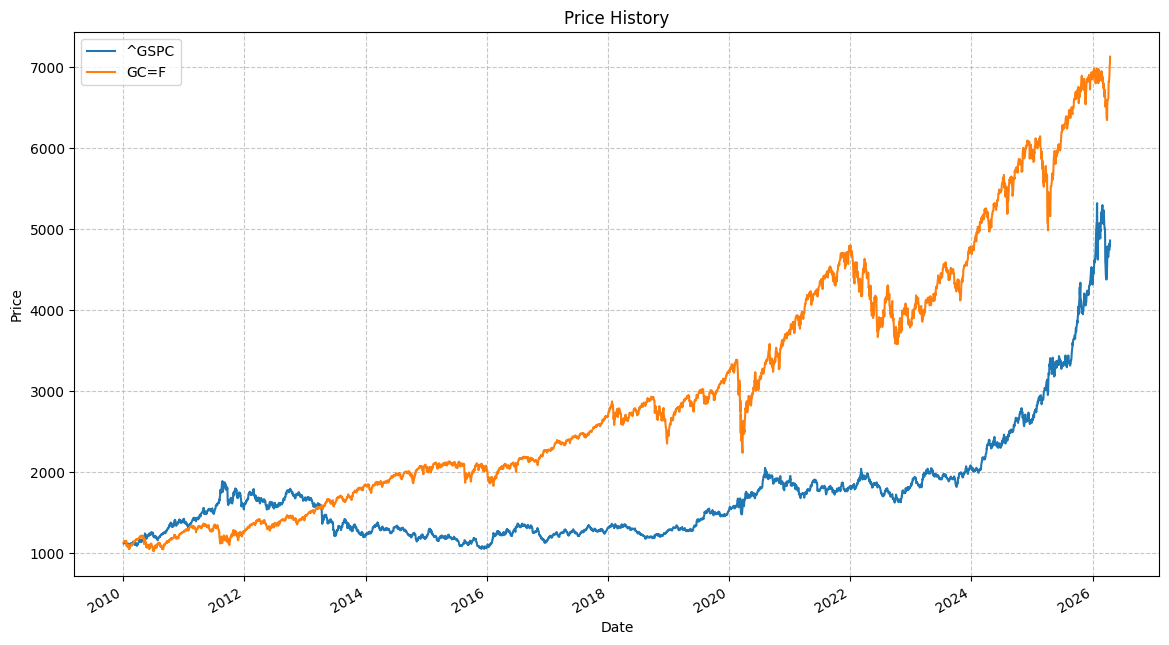

In [5]:
plt.figure(figsize=(14, 8))
data.plot(ax=plt.gca())
plt.title('Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(tickers)
plt.grid(linestyle='--', alpha=0.7)
plt.show()      

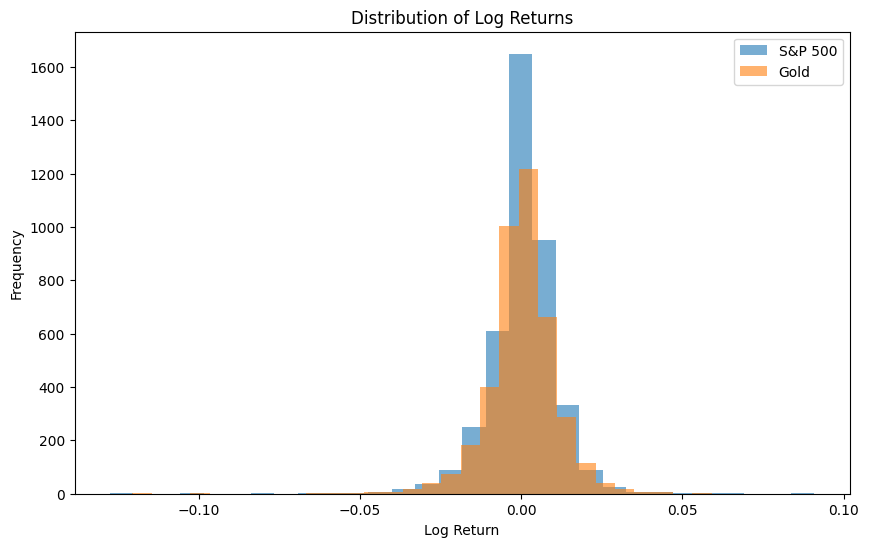

S&P 500 Skewness: -0.6072, Kurtosis: 13.4543
Gold Skewness: -0.8540, Kurtosis: 8.8815


In [6]:
plt.figure(figsize=(10,6))
plt.hist(log_returns['^GSPC'], bins=30, alpha=0.6, label='S&P 500')
plt.hist(log_returns['GC=F'], bins=30, alpha=0.6, label='Gold')
plt.title('Distribution of Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')         
plt.legend()
plt.show()

sp500_stats = stats.skew(log_returns['^GSPC']), stats.kurtosis(log_returns['^GSPC'])
gold_stats = stats.skew(log_returns['GC=F']), stats.kurtosis(log_returns['GC=F'])

print(f"S&P 500 Skewness: {sp500_stats[0]:.4f}, Kurtosis: {sp500_stats[1]:.4f}")
print(f"Gold Skewness: {gold_stats[0]:.4f}, Kurtosis: {gold_stats[1]:.4f}")

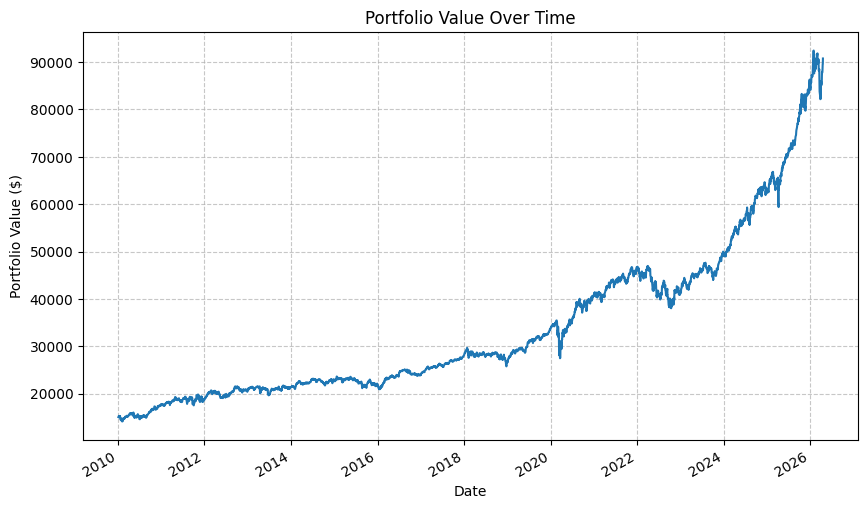

In [7]:
w_sp500 = 0.6
w_gold = 0.4

equity = 15000

port_ret = w_sp500 * pct_returns['^GSPC'] + w_gold * pct_returns['GC=F']
equity_curve = equity * (1 + port_ret).cumprod()

plt.figure(figsize=(10,6))
equity_curve.plot(ax=plt.gca())
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

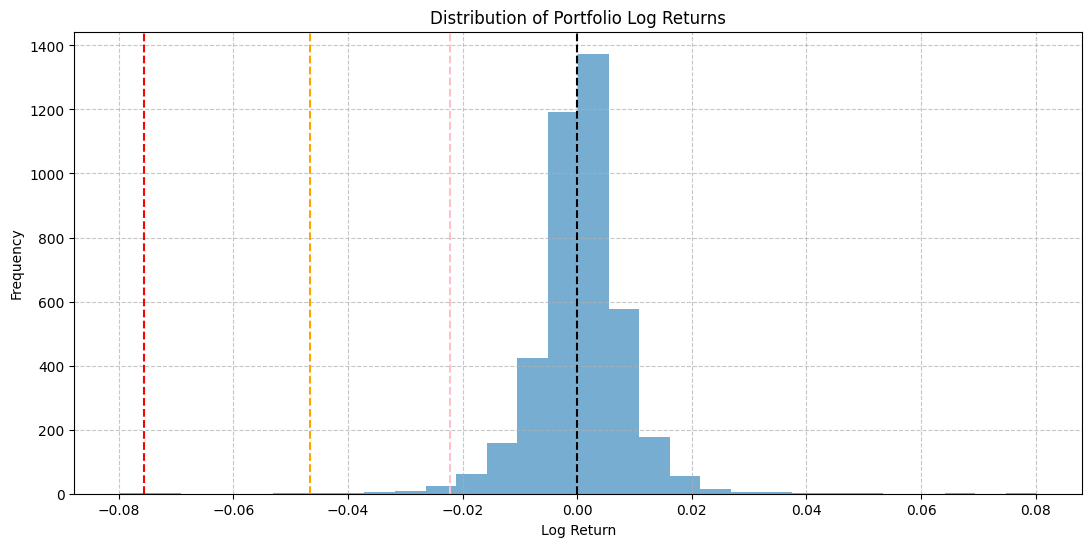

Portfolio Skewness: -0.3155, Kurtosis: 11.3028
1% VaR: -0.0223
0.1% VaR: -0.0466
0.01% VaR: -0.0757


In [8]:
q1 = port_ret.quantile(0.01)
q01 = port_ret.quantile(0.001)
q001 = port_ret.quantile(0.0001)

plt.figure(figsize=(13,6))
port_ret.hist(bins=30, alpha=0.6)
plt.title('Distribution of Portfolio Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--')
plt.axvline(q1, color='pink', linestyle='--', label='Var @ 1%')
plt.axvline(q01, color='orange', linestyle='--', label='Var @ 0.1%')
plt.axvline(q001, color='red', linestyle='--', label='Var @ 0.01%') 
plt.grid(linestyle='--', alpha=0.7)
plt.show()

port_ret_stats = stats.skew(port_ret), stats.kurtosis(port_ret)
print(f"Portfolio Skewness: {port_ret_stats[0]:.4f}, Kurtosis: {port_ret_stats[1]:.4f}")
print(f"1% VaR: {q1:.4f}")
print(f"0.1% VaR: {q01:.4f}")
print(f"0.01% VaR: {q001:.4f}")

#### 1. Calculating VAR using Simple Moving Average Parametric Approach 
Methodology: Uses rolling volatility estimate with normal distribution assumption.

In [9]:
window = 252 
rolling_std_sma = port_ret.rolling(window=window).std()
sma_var_daily = port_ret.mean() - 2.33 * rolling_std_sma  # 99% confidence (z=2.33)
sma_var_euros_wcc = (sma_var_daily.min() * equity)
sma_var_euros_best = (sma_var_daily.max() * equity)
sma_var_euros_last = (sma_var_daily.iloc[-1] * equity)

print("Worst Case Scenario")
print(f"SMA VaR (1%, daily): {sma_var_daily.min():.4f} ({sma_var_euros_wcc:.2f}€)")
print()
print("Best Case Scenario")
print(f"SMA VaR (1%, daily): {sma_var_daily.max():.4f} ({sma_var_euros_best:.2f}€)")
print()
print("Last Value")
print(f"SMA VaR (1%, daily): {sma_var_daily.iloc[-1]:.4f} ({sma_var_euros_last:.2f}€)")

Worst Case Scenario
SMA VaR (1%, daily): -0.0348 (-521.39€)

Best Case Scenario
SMA VaR (1%, daily): -0.0068 (-102.04€)

Last Value
SMA VaR (1%, daily): -0.0196 (-293.78€)


#### 2. Calculating VAR using Exponentially Weighted Moving Average
Methodology: Gives more weight to recent volatility. Lambda (λ) is typically 0.94 for daily data (RiskMetrics standard).

In [10]:
# Determine λ based on volatility characteristics
# For daily data: λ ≈ 0.94 (standard); higher volatility -> higher λ
volatility = port_ret.std()
if volatility > 0.02:  # High volatility threshold
    lambda_ewma = 0.96
elif volatility > 0.01:
    lambda_ewma = 0.94
else:
    lambda_ewma = 0.92

print(f"Selected λ = {lambda_ewma:.2f} (volatility: {volatility:.4f})")
print()

# RiskMetrics-style EWMA variance with direct alpha mapping (alpha = 1 - λ)
alpha = 1 - lambda_ewma
ewma_var = port_ret.ewm(alpha=alpha, adjust=False).var(bias=False)
ewma_std = np.sqrt(ewma_var)
ewma_var_daily = port_ret.mean() - 2.33 * ewma_std

ewma_var_euros = ewma_var_daily.iloc[-1] * equity
ewma_var_euros_wcc = ewma_var_daily.min() * equity
ewma_var_euros_best = ewma_var_daily.max() * equity
ewma_label = f"EWMA (λ={lambda_ewma:.2f})"

print("Last Value")
print(f"EWMA VaR (1%, daily): {ewma_var_daily.iloc[-1]:.4f} ({ewma_var_euros:.2f}€)")
print()
print("Worst Case Scenario")
print(f"EWMA VaR (1%, daily): {ewma_var_daily.min():.4f} ({ewma_var_euros_wcc:.2f}€)")
print()
print("Best Case Scenario")
print(f"EWMA VaR (1%, daily): {ewma_var_daily.max():.4f} ({ewma_var_euros_best:.2f}€)")

Selected λ = 0.92 (volatility: 0.0080)

Last Value
EWMA VaR (1%, daily): -0.0268 (-401.66€)

Worst Case Scenario
EWMA VaR (1%, daily): -0.0936 (-1403.38€)

Best Case Scenario
EWMA VaR (1%, daily): -0.0042 (-63.53€)


#### 3. Calculating VAR using Historical Simulation (Non-Parametric Approach)
Methodology: Uses empirical distribution of past returns; no distribution assumption needed.

In [11]:
# Historical simulation with rolling window to derive worst/best scenarios
historical_var_series = port_ret.rolling(window=window).quantile(0.01).dropna()
historical_var_daily = historical_var_series.iloc[-1]
historical_var_euros = historical_var_daily * equity
historical_var_euros_wcc = historical_var_series.min() * equity
historical_var_euros_best = historical_var_series.max() * equity

print("Last Value")
print(f"Historical VaR (1%, daily): {historical_var_daily:.4f} ({historical_var_euros:.2f}€)")
print()
print("Worst Case Scenario")
print(f"Historical VaR (1%, daily): {historical_var_series.min():.4f} ({historical_var_euros_wcc:.2f}€)")
print()
print("Best Case Scenario")
print(f"Historical VaR (1%, daily): {historical_var_series.max():.4f} ({historical_var_euros_best:.2f}€)")

Last Value
Historical VaR (1%, daily): -0.0241 (-361.35€)

Worst Case Scenario
Historical VaR (1%, daily): -0.0441 (-661.94€)

Best Case Scenario
Historical VaR (1%, daily): -0.0071 (-106.25€)


#### 4. Calculating VAR using Filtered Historical Simulation (Hybrid Approach) 
Methodology: Combines volatility weighting with historical simulation to account for changing market conditions.

In [12]:
# Filtered historical simulation with time-varying volatility scaling
rolling_vol = port_ret.rolling(window=window).std()
current_vol = rolling_vol.iloc[-1]

# Scale past returns into the current volatility regime
vol_ratio_series = current_vol / rolling_vol.replace(0, np.nan)
adjusted_returns = port_ret * vol_ratio_series
hybrid_var_series = adjusted_returns.rolling(window=window).quantile(0.01).dropna()

hybrid_var_daily = hybrid_var_series.iloc[-1]
hybrid_var_euros = hybrid_var_daily * equity
hybrid_var_euros_wcc = hybrid_var_series.min() * equity
hybrid_var_euros_best = hybrid_var_series.max() * equity

print("Last Value")
print(f"Hybrid VaR (1%, daily): {hybrid_var_daily:.4f} ({hybrid_var_euros:.2f}€)")
print()
print("Worst Case Scenario")
print(f"Hybrid VaR (1%, daily): {hybrid_var_series.min():.4f} ({hybrid_var_euros_wcc:.2f}€)")
print()
print("Best Case Scenario")
print(f"Hybrid VaR (1%, daily): {hybrid_var_series.max():.4f} ({hybrid_var_euros_best:.2f}€)")

Last Value
Hybrid VaR (1%, daily): -0.0220 (-329.65€)

Worst Case Scenario
Hybrid VaR (1%, daily): -0.0505 (-758.20€)

Best Case Scenario
Hybrid VaR (1%, daily): -0.0136 (-203.88€)


#### 5. Calculating VAR using Monte Carlo Simulation
Methodology: Generates random paths based on estimated parameters (drift + volatility); can use either parametric (normal) or non-parametric (bootstrap).

In [13]:
# Monte Carlo - Parametric approach (Geometric Brownian Motion)
np.random.seed(42)
n_simulations = 10000
n_days = 1  # 1-day VaR
n_runs = 100  # Multiple runs to capture uncertainty

mu = port_ret.mean()
sigma = port_ret.std()

# Run multiple MC simulations to capture uncertainty
mc_var_estimates = []
for _ in range(n_runs):
    Z = np.random.standard_normal((n_simulations, n_days))
    simulated_returns = mu + sigma * Z
    var_estimate = np.percentile(simulated_returns, 1)
    mc_var_estimates.append(var_estimate)

mc_var_daily = np.median(mc_var_estimates)
mc_var_euros = mc_var_daily * equity
mc_var_euros_wcc = np.min(mc_var_estimates) * equity
mc_var_euros_best = np.max(mc_var_estimates) * equity

print("\n" + "="*60)
print("Monte Carlo - Parametric Approach")
print("="*60)
print("Worst Case Scenario")
print(f"Monte Carlo VaR (1%, daily): {np.min(mc_var_estimates):.4f} ({mc_var_euros_wcc:.2f}€)")
print()
print("Best Case Scenario")
print(f"Monte Carlo VaR (1%, daily): {np.max(mc_var_estimates):.4f} ({mc_var_euros_best:.2f}€)")
print()
print("Median Value")
print(f"Monte Carlo VaR (1%, daily): {mc_var_daily:.4f} ({mc_var_euros:.2f}€)")

# Non-parametric Monte Carlo (Bootstrap)
print("\n" + "="*60)
print("Monte Carlo - Bootstrap Approach")
print("="*60)

mc_bootstrap_var_estimates = []
for _ in range(n_runs):
    bootstrap_returns = np.random.choice(port_ret.values, size=(n_simulations, n_days), replace=True)
    var_estimate = np.percentile(bootstrap_returns, 1)
    mc_bootstrap_var_estimates.append(var_estimate)

mc_bootstrap_var_daily = np.median(mc_bootstrap_var_estimates)
mc_bootstrap_var_euros = mc_bootstrap_var_daily * equity
mc_bootstrap_var_euros_wcc = np.min(mc_bootstrap_var_estimates) * equity
mc_bootstrap_var_euros_best = np.max(mc_bootstrap_var_estimates) * equity

print("Worst Case Scenario")
print(f"Monte Carlo Bootstrap VaR (1%, daily): {np.min(mc_bootstrap_var_estimates):.4f} ({mc_bootstrap_var_euros_wcc:.2f}€)")
print()
print("Best Case Scenario")
print(f"Monte Carlo Bootstrap VaR (1%, daily): {np.max(mc_bootstrap_var_estimates):.4f} ({mc_bootstrap_var_euros_best:.2f}€)")
print()
print("Median Value")
print(f"Monte Carlo Bootstrap VaR (1%, daily): {mc_bootstrap_var_daily:.4f} ({mc_bootstrap_var_euros:.2f}€)")


Monte Carlo - Parametric Approach
Worst Case Scenario
Monte Carlo VaR (1%, daily): -0.0190 (-284.26€)

Best Case Scenario
Monte Carlo VaR (1%, daily): -0.0175 (-262.11€)

Median Value
Monte Carlo VaR (1%, daily): -0.0181 (-271.63€)

Monte Carlo - Bootstrap Approach
Worst Case Scenario
Monte Carlo Bootstrap VaR (1%, daily): -0.0246 (-368.32€)

Best Case Scenario
Monte Carlo Bootstrap VaR (1%, daily): -0.0203 (-304.29€)

Median Value
Monte Carlo Bootstrap VaR (1%, daily): -0.0223 (-334.84€)


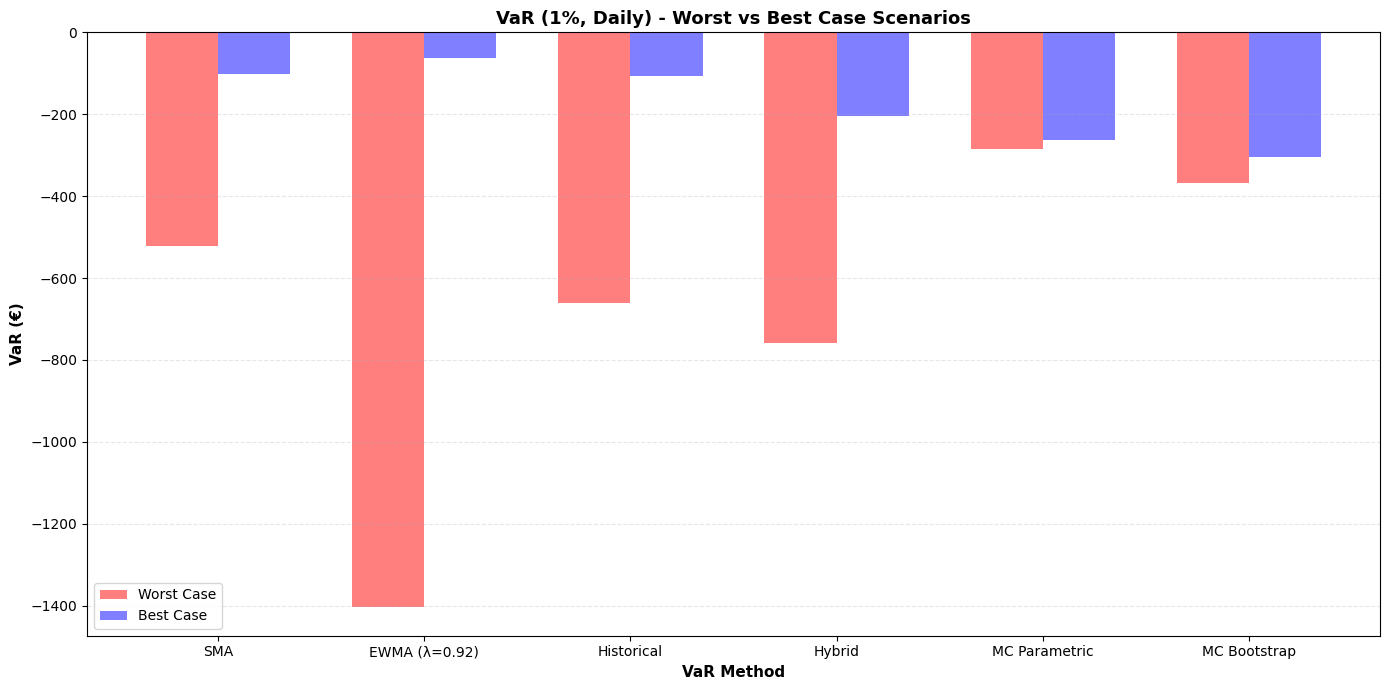


VaR COMPARISON SUMMARY (1%, Daily) - WORST vs BEST CASE
Method                    Worst Case (€)       Best Case (€)       
----------------------------------------------------------------------
SMA                               -521.39  |          -102.04
EWMA (λ=0.92)                    -1403.38  |           -63.53
Historical                        -661.94  |          -106.25
Hybrid                            -758.20  |          -203.88
MC Parametric                     -284.26  |          -262.11
MC Bootstrap                      -368.32  |          -304.29


In [14]:
# Compile all VaR estimates with best/worst case scenarios
var_methods_worst = {
    'SMA': sma_var_euros_wcc,
    ewma_label: ewma_var_euros_wcc,
    'Historical': historical_var_euros_wcc,
    'Hybrid': hybrid_var_euros_wcc,
    'MC Parametric': mc_var_euros_wcc,
    'MC Bootstrap': mc_bootstrap_var_euros_wcc
}

var_methods_best = {
    'SMA': sma_var_euros_best,
    ewma_label: ewma_var_euros_best,
    'Historical': historical_var_euros_best,
    'Hybrid': hybrid_var_euros_best,
    'MC Parametric': mc_var_euros_best,
    'MC Bootstrap': mc_bootstrap_var_euros_best
}

# Create comparison chart with worst/best scenarios only
methods = list(var_methods_worst.keys())
worst_vals = [var_methods_worst[m] for m in methods]
best_vals = [var_methods_best[m] for m in methods]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width / 2, worst_vals, width, label='Worst Case', color='red', alpha=0.5)
ax.bar(x + width / 2, best_vals, width, label='Best Case', color='blue', alpha=0.5)

ax.set_xlabel('VaR Method', fontsize=11, fontweight='bold')
ax.set_ylabel('VaR (€)', fontsize=11, fontweight='bold')
ax.set_title('VaR (1%, Daily) - Worst vs Best Case Scenarios', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=0, ha='center')
ax.legend(fontsize=10)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Comprehensive summary table with worst/best scenarios
print("\n" + "=" * 70)
print("VaR COMPARISON SUMMARY (1%, Daily) - WORST vs BEST CASE")
print("=" * 70)
print(f"{'Method':<25} {'Worst Case (€)':<20} {'Best Case (€)':<20}")
print("-" * 70)

for method in var_methods_worst.keys():
    worst = var_methods_worst[method]
    best = var_methods_best[method]
    print(f"{method:<25} {worst:>15.2f}  |  {best:>15.2f}")

print("=" * 70)

#### **Comments and Interpretation**

- The spread between worst and best scenarios is a proxy for **model sensitivity to market regime changes**.
- Based on current results, **EWMA is the most regime-sensitive**, while **Monte Carlo parametric is the most stable**.

**Interpretation by method**

- **SMA :** Wide interval because equal-weight rolling volatility reacts to the sample window but not as aggressively as EWMA. This method gives us a useful baseline, but can lag when volatility changes fast.

- **EWMA:** Largest interval between best and worst case scenario, which is consistent with volatility clustering and the EWMA mechanism that places high weight on recent moves. The method is best fit for detecting stress quickly, but can become very conservative during shock periods.

- **Historical:** Captures empirical tail behavior without normality assumptions, but is still dependent on the selected rolling window and past regime composition.

- **Hybrid / Filtered Historical:** More conservative than plain Historical in stressed scenarios because volatility scaling amplifies losses when current regime is riskier. Usually a more robust non-parametric choice when volatility is not stationary.

- **Monte Carlo Parametric:** Very tight range across simulation runs because uncertainty here is mainly Monte Carlo sampling noise under a fixed distributional assumption. Although the outputs are stable, it can lead to understate risk if tails are fatter than Gaussian.

- **Monte Carlo Bootstrap:** Still a relatively tight range between best and worst case, but wider than parametric MC because it resamples empirical returns, so tail events in data are retained. Can be a better practical Monte Carlo alternative when the normality assumption does not hold.

**Takeaways**

- If you want a **conservative capital/risk buffer**, EWMA and Hybrid provide the strongest stress signals.

- If you want **stable daily monitoring**, MC methods (especially parametric) are smoother but potentially optimistic in crisis tails.


#### 6. Parametric SMA: Weekly, Monthly, Annual VaR (1%) and Conversion to VaR (10%)
Methodology: Use the latest SMA daily volatility estimate and scale to longer horizons with square-root-of-time. Then convert VaR (1%) to VaR (10%) using normal quantile scaling.

In [15]:
# 6) Parametric SMA: weekly/monthly/annual VaR (1%) and conversion to VaR (10%)
mu_daily = port_ret.mean()
sigma_daily_sma = rolling_std_sma.iloc[-1]  # latest SMA volatility estimate

z_1 = stats.norm.ppf(0.01)   # 1% left-tail quantile
z_10 = stats.norm.ppf(0.10)  # 10% left-tail quantile

horizons = {
    'Weekly (5d)': 5,
    'Monthly (21d)': 21,
    'Annual (252d)': 252
}

sma_horizon_rows = []
for horizon, h in horizons.items():
    mu_h = mu_daily * h
    sigma_h = sigma_daily_sma * np.sqrt(h)

    # Parametric VaR at 1%
    var_1pct = mu_h + z_1 * sigma_h

    # Convert VaR(1%) -> VaR(10%) via z-score ratio (same horizon mean and volatility)
    var_10pct_converted = mu_h + (z_10 / z_1) * (var_1pct - mu_h)
    var_10pct_direct = mu_h + z_10 * sigma_h

    sma_horizon_rows.append({
        'Horizon': horizon,
        'VaR 1% (return)': var_1pct,
        'VaR 1% (€)': var_1pct * equity,
        'VaR 10% converted (return)': var_10pct_converted,
        'VaR 10% converted (€)': var_10pct_converted * equity,
        'Check VaR 10% direct (return)': var_10pct_direct
    })

sma_horizon_var_df = pd.DataFrame(sma_horizon_rows)

print('SMA Parametric VaR Across Horizons')
print('=' * 95)
print(
    sma_horizon_var_df[
        ['Horizon', 'VaR 1% (return)', 'VaR 1% (€)', 'VaR 10% converted (return)', 'VaR 10% converted (€)']
    ].to_string(index=False, float_format=lambda x: f'{x:.6f}')
)

# Consistency check for conversion vs direct 10% formula
max_diff = np.max(np.abs(
    sma_horizon_var_df['VaR 10% converted (return)'] - sma_horizon_var_df['Check VaR 10% direct (return)']
))
print('\nMax conversion vs direct difference:', f'{max_diff:.12f}')

SMA Parametric VaR Across Horizons
      Horizon  VaR 1% (return)   VaR 1% (€)  VaR 10% converted (return)  VaR 10% converted (€)
  Weekly (5d)        -0.042419  -636.284557                   -0.022308            -334.626389
Monthly (21d)        -0.081859 -1227.887815                   -0.040645            -609.672535
Annual (252d)        -0.198987 -2984.812500                   -0.056217            -843.251949

Max conversion vs direct difference: 0.000000000000


#### 7. Non-Parametric Stressed VaR (1%) and Comparison to Baseline Non-Parametric VaR
Methodology: Select a one-year stressed period (COVID crisis window), compute historical 1% VaR in euros for that period, compare against full-sample non-parametric VaR, and interpret the change in tail risk.

Stressed Non-Parametric VaR (1%)
Stress period: 2020-02-20 to 2021-02-19 (one year)
Observations in stressed sample: 253
Stressed VaR (1%, daily): -0.0441 (-661.77€)

Comparison vs baseline non-parametric VaR (full sample)
Baseline VaR (1%, daily): -0.0223 (-334.01€)
Difference (Stressed - Baseline): -327.76€
Absolute VaR change: 98.13%

Interpretation: Stressed VaR is more conservative than baseline, indicating higher tail risk during crisis conditions.


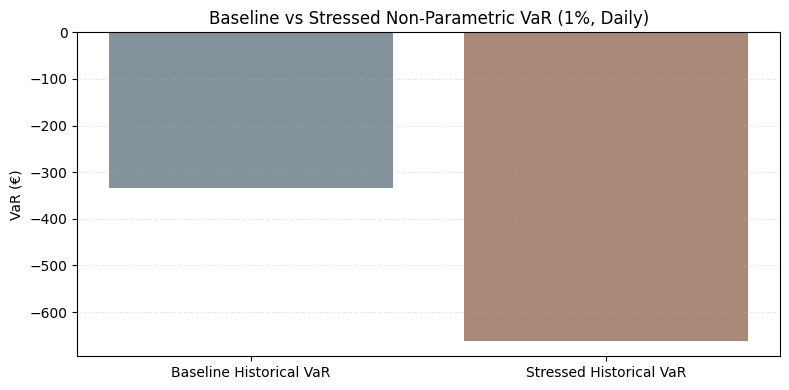

In [16]:
# 7) Non-parametric stressed VaR (1%) using a one-year crisis period
stress_start = '2020-02-20'
stress_end = '2021-02-19'

stressed_ret = port_ret.loc[stress_start:stress_end].dropna()
if stressed_ret.empty:
    raise ValueError('No observations found in the selected stressed period. Choose a different one-year crisis window.')

# Stressed non-parametric VaR (historical quantile in stressed window)
stressed_var_daily = stressed_ret.quantile(0.01)
stressed_var_euros = stressed_var_daily * equity

# Baseline non-parametric VaR from full sample (same definition as section 2.c style estimate)
baseline_nonparam_var_daily = port_ret.quantile(0.01)
baseline_nonparam_var_euros = baseline_nonparam_var_daily * equity

# Comparison metrics
delta_euros = stressed_var_euros - baseline_nonparam_var_euros
pct_change_abs = (abs(stressed_var_euros) / abs(baseline_nonparam_var_euros) - 1) * 100

print('Stressed Non-Parametric VaR (1%)')
print('=' * 70)
print(f'Stress period: {stress_start} to {stress_end} (one year)')
print(f'Observations in stressed sample: {len(stressed_ret)}')
print(f'Stressed VaR (1%, daily): {stressed_var_daily:.4f} ({stressed_var_euros:.2f}€)')
print()
print('Comparison vs baseline non-parametric VaR (full sample)')
print(f'Baseline VaR (1%, daily): {baseline_nonparam_var_daily:.4f} ({baseline_nonparam_var_euros:.2f}€)')
print(f'Difference (Stressed - Baseline): {delta_euros:.2f}€')
print(f'Absolute VaR change: {pct_change_abs:.2f}%')

if abs(stressed_var_euros) > abs(baseline_nonparam_var_euros):
    print('\nInterpretation: Stressed VaR is more conservative than baseline, indicating higher tail risk during crisis conditions.')
else:
    print('\nInterpretation: Stressed VaR is not more conservative than baseline for this selected period; review the stress window selection.')

# Visual comparison
plt.figure(figsize=(8, 4))
labels = ['Baseline Historical VaR', 'Stressed Historical VaR']
values = [baseline_nonparam_var_euros, stressed_var_euros]
colors = ['#6F7F8A', '#9A7660']

plt.bar(labels, values, color=colors, alpha=0.85)
plt.axhline(0, color='black', linewidth=0.7)
plt.ylabel('VaR (€)')
plt.title('Baseline vs Stressed Non-Parametric VaR (1%, Daily)')
plt.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()